# Ask with a list of images

Minimal demo: send a list of images plus a text prompt to `ask_chatgpt()`.

Edit `IMAGE_PATHS` and `PROMPT` below, then run all cells.

In [13]:
print("Importing libraries...")
import sys, os
import time

sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning.chatgpt_client import ask_chatgpt

Importing libraries...


## Configure images and prompt

In [14]:
import json
from collections import defaultdict
from pathlib import Path
from PIL import Image as PILImage

# Load the FULL reference bank (all 3 base views x 8 rotations = 24 images) from the
# same JSON the orchestrator's camera specialist uses (see
# visualization_orchestrator.specialists.load_simple_reference_bank) -- node_id ->
# description, with each image conventionally at "<node_id>.png" next to the JSON.
REFERENCE_BANK_DIR = "../reference_views_medical/skull"
with open(f"{REFERENCE_BANK_DIR}/reference_views_simple.json") as f:
    _node_descriptions = json.load(f)

# The reference photos are 1254x1254 real photographs (~2MB each) -- attaching all 24
# of them at full resolution in one call is what caused the ContextWindowExceededError.
# Downscale to RESIZE_MAX_DIMENSION on the longest side, same threshold
# blind_visual_rollout_agent.py already uses for this exact reason
# (REFERENCE_BANK_MAX_DIMENSION there), cached so repeat runs don't re-resize.
RESIZE_MAX_DIMENSION = 800
RESIZE_CACHE_DIR = Path("../output/_notebook_resized_cache")


def resized_for_upload(image_path: str) -> str:
    source = Path(image_path)
    with PILImage.open(source) as probe:
        width, height = probe.size
    if max(width, height) <= RESIZE_MAX_DIMENSION:
        return image_path
    RESIZE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = RESIZE_CACHE_DIR / source.name
    if not cache_path.exists() or cache_path.stat().st_mtime < source.stat().st_mtime:
        with PILImage.open(source) as img:
            scale = RESIZE_MAX_DIMENSION / max(width, height)
            resized = img.convert("RGB").resize(
                (round(width * scale), round(height * scale)), PILImage.LANCZOS
            )
            resized.save(cache_path)
    return str(cache_path)


REFERENCE_IMAGES = [
    (node_id, resized_for_upload(f"{REFERENCE_BANK_DIR}/{node_id}.png"), description)
    for node_id, description in sorted(_node_descriptions.items())
]
print(f"Loaded {len(REFERENCE_IMAGES)} reference images (resized to max {RESIZE_MAX_DIMENSION}px).")

QUERY_IMAGES = [
    ("CANDIDATE_DPP5K", "../output/orchestrator_notebook/screenshots/blind_candidates/step_000/candidate_dpp5k.png"),
]

IMAGE_PATHS = [path for _, path in QUERY_IMAGES] + [path for _, path, _ in REFERENCE_IMAGES]

# Group references by SIDE (the first word of each description -- "Right"/"Front"/
# "Left") rather than an arbitrary chunk size: each side's ~8 rotations comfortably fit
# in one call (avoiding the earlier ContextWindowExceededError from sending all 24 at
# once), and the grouping is meaningful -- one call per side, asking a direct yes/no
# "does this match this side" question, instead of chunking arbitrarily and comparing
# numeric scores across unrelated groups.
SIDE_GROUPS = defaultdict(list)
for node_id, path, description in REFERENCE_IMAGES:
    side_label = description.split()[0]  # "Right" | "Front" | "Left"
    SIDE_GROUPS[side_label].append((node_id, path, description))
print(f"Grouped into {len(SIDE_GROUPS)} side(s): " +
      ", ".join(f"{label}={len(group)}" for label, group in SIDE_GROUPS.items()))


Loaded 24 reference images (resized to max 800px).
Grouped into 3 side(s): Right=8, Front=8, Left=8


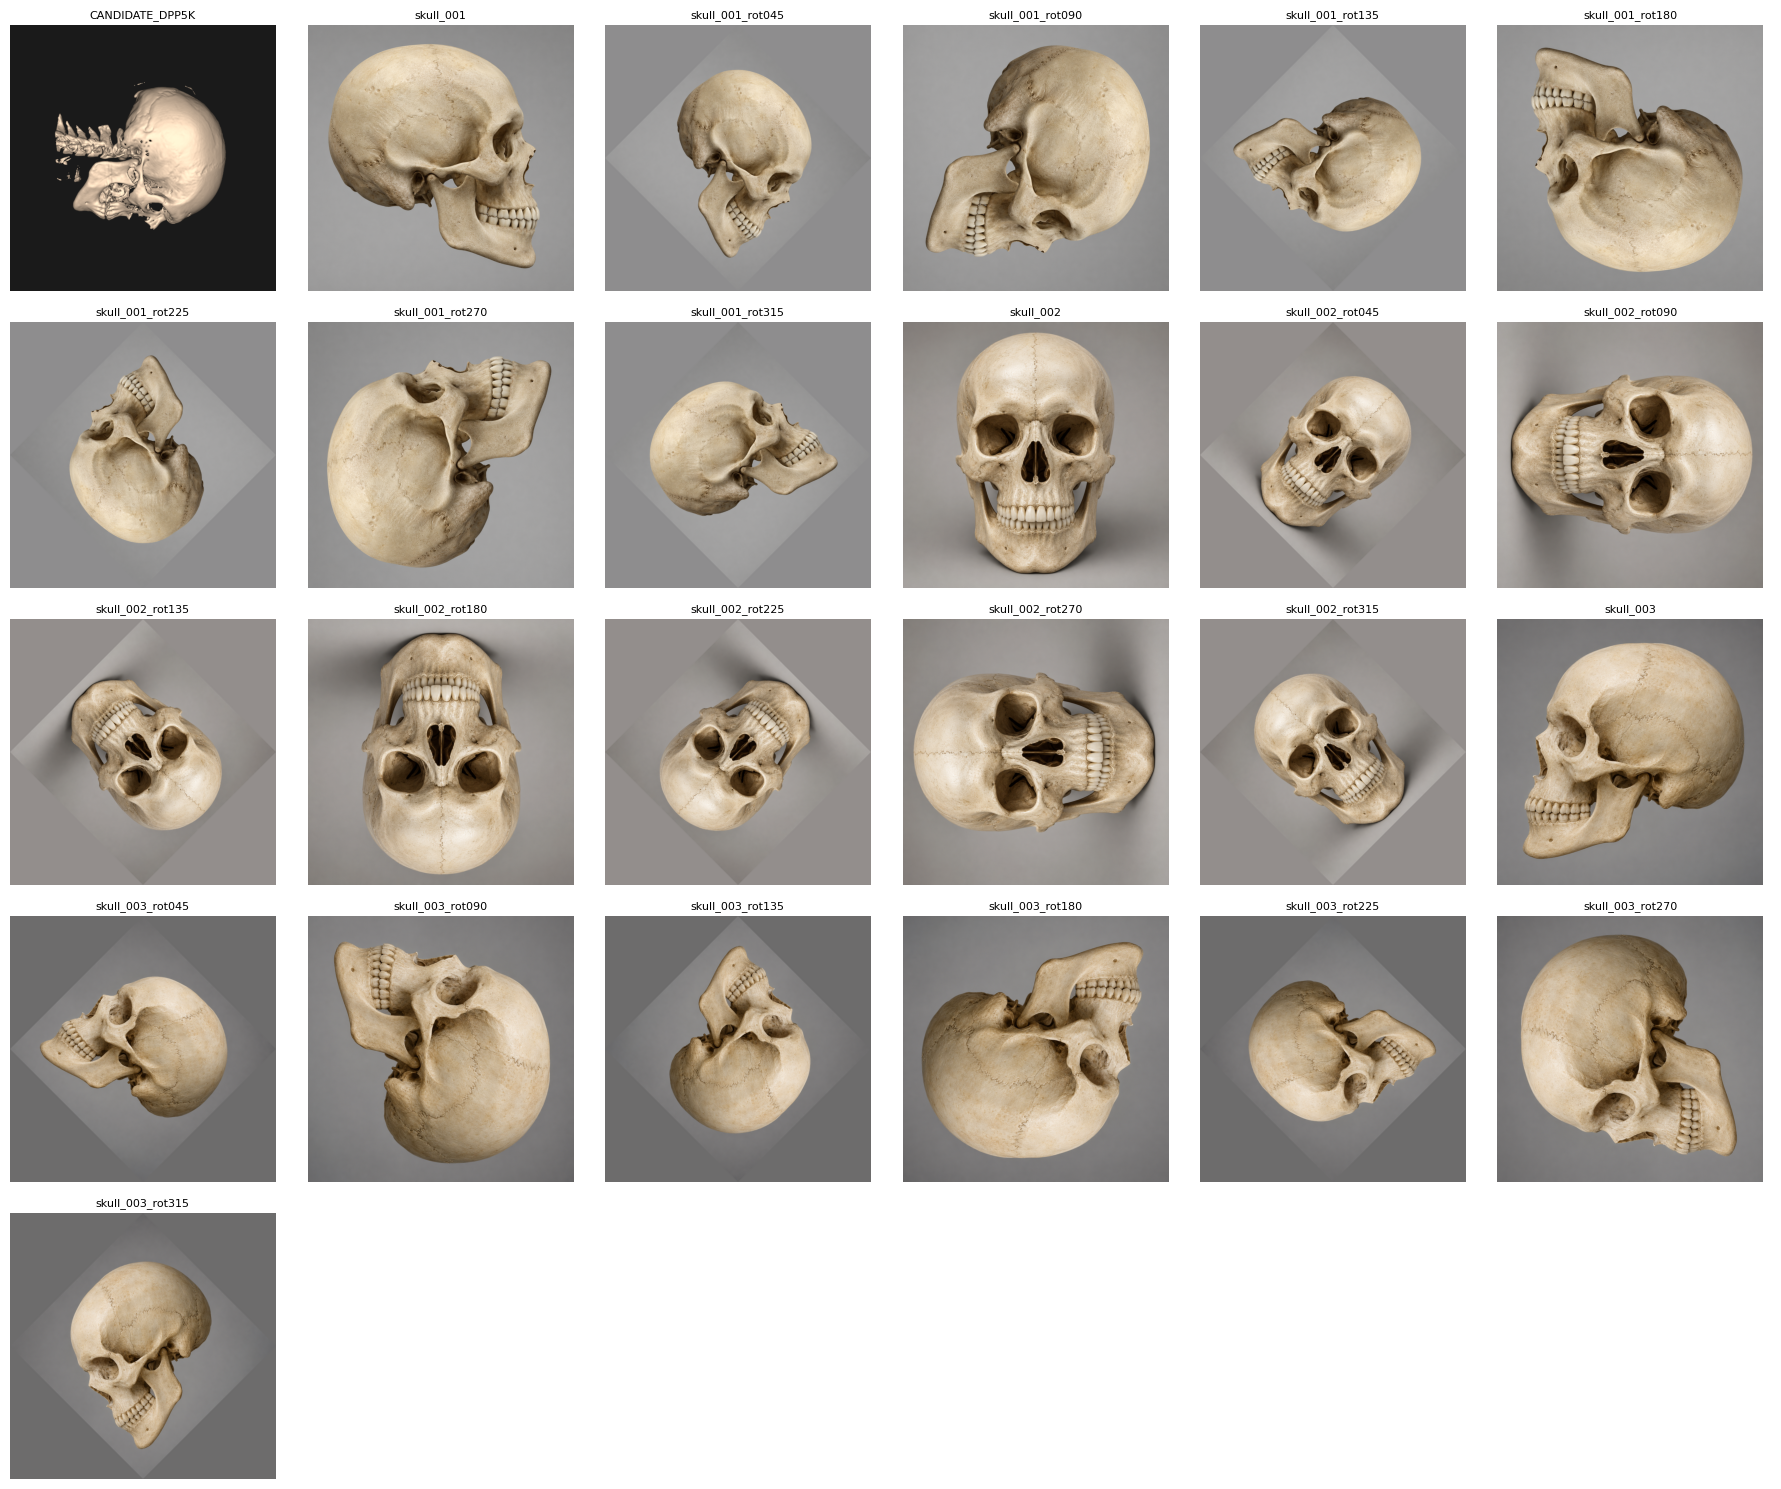

In [15]:
import math
from PIL import Image
import matplotlib.pyplot as plt

_labels = [label for label, _ in QUERY_IMAGES] + [node_id for node_id, _, _ in REFERENCE_IMAGES]

_columns = min(6, len(IMAGE_PATHS))
_rows = math.ceil(len(IMAGE_PATHS) / _columns)
fig, axes = plt.subplots(_rows, _columns, figsize=(3 * _columns, 3 * _rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, path, label in zip(axes, IMAGE_PATHS, _labels):
    ax.imshow(Image.open(path))
    ax.set_title(label, fontsize=8)
    ax.axis("off")
for ax in axes[len(IMAGE_PATHS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Run

In [7]:
def build_prompt(reference_group, side_label):
    ids_block = "\n".join(
        f"{i + 2}. {node_id} — {desc}" for i, (node_id, _, desc) in enumerate(reference_group)
    )
    valid_ids = " | ".join(node_id for node_id, _, _ in reference_group) + " | none"
    return f"""
The images are provided in the following order:

Query image:
1. CANDIDATE_DPP5K

Reference images (all {len(reference_group)} are different rotation angles of the SAME
{side_label.upper()} viewpoint of the skull):
{ids_block}

Determine whether the query image shows the skull from this same {side_label.upper()}
side (at any of the rotation angles shown), or from a clearly different side.

Evaluate the visible anatomical structures and the direction from which the skull is
viewed. Ignore image quality, lighting, scale, cropping, and rendering style unless
they affect orientation recognition. Do not infer the answer from filenames, IDs,
file paths, or camera-action names -- base your answer only on visual similarity.

Return only valid JSON in this exact format:
{{
  "CANDIDATE_DPP5K": {{
    "matches_this_side": true | false,
    "closest_reference_id": "{valid_ids}",
    "reasoning": "State which side the query image actually shows and why -- name
the specific reference image (by ID) it looks most similar to, if any, and what
about it looks similar or different."
  }}
}}
"""


screenshot_path = QUERY_IMAGES[0][1]

print("LLM starts processing...")
start = time.perf_counter()

side_results = {}
for side_label, group in SIDE_GROUPS.items():
    print(f"\n--- Comparing against the {side_label.upper()} side ({len(group)} rotations) ---")
    response_text = ask_chatgpt(
        prompt=build_prompt(group, side_label),
        screenshot_path=screenshot_path,
        reference_items=group,
    )
    print(response_text)
    side_results[side_label] = response_text

elapsed = time.perf_counter() - start
print(f"\n[Elapsed: {elapsed:.2f}s]")


LLM starts processing...
```json
{
  "CANDIDATE_DPP5K": {
    "reference_id": "skull_003",
    "similarity_score": "95",
    "reason": "Both show a left lateral view of the skull. The query image displays the left side with visible zygomatic arch, mandible, temporal bone, and auditory structures positioned on the left side of the cranium, matching the orientation of skull_003."
  }
}
```

[Elapsed: 6.37s]


In [ ]:
# Show each side's verdict, then state the conclusion in plain terms -- no numeric
# score anywhere, just which side matched (if any) and why.
import re


def extract_json(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)
    return json.loads(match.group(0)) if match else None


print("Per-side verdicts:\n")
matches = []
for side_label, text in side_results.items():
    parsed = extract_json(text)
    entry = (parsed or {}).get("CANDIDATE_DPP5K", {})
    matched = entry.get("matches_this_side")
    print(f"[{side_label.upper()}] matches_this_side={matched}")
    print(f"  closest_reference_id: {entry.get('closest_reference_id')}")
    print(f"  reasoning: {entry.get('reasoning')}\n")
    if matched:
        matches.append((side_label, entry))

print("=" * 60)
if len(matches) == 1:
    side_label, entry = matches[0]
    print(f"CONCLUSION: this is the {side_label.upper()} side, most similar to "
          f"{entry.get('closest_reference_id')}.")
    print(f"Reasoning: {entry.get('reasoning')}")
elif len(matches) > 1:
    print(f"CONCLUSION: ambiguous -- more than one side claimed a match: "
          f"{[s for s, _ in matches]}. Review the reasoning above.")
else:
    print("CONCLUSION: no side reported a match -- the query image doesn't clearly "
          "resemble any of the reference sides.")


## One-by-one comparison (no batching at all)

Instead of grouping references by side, compare the query image against EVERY reference image individually -- one `ask_chatgpt` call per reference (24 calls for the full bank). Slower and more expensive than the side-grouped comparison above, but each call only ever sees ONE reference image at a time, so there is nothing for the model to mix up between images.

In [ ]:
def build_single_prompt(reference_id, description):
    return f"""
The images are provided in the following order:

Query image:
1. CANDIDATE_DPP5K

Reference image:
2. {reference_id} — {description}

Determine whether the query image shows the skull from the SAME viewpoint as this
one reference image.

Evaluate the visible anatomical structures and the direction from which the skull is
viewed. Ignore image quality, lighting, scale, cropping, and rendering style unless
they affect orientation recognition. Do not infer the answer from filenames, IDs,
file paths, or camera-action names -- base your answer only on visual similarity.

Return only valid JSON in this exact format:
{{
  "CANDIDATE_DPP5K": {{
    "matches_this_reference": true | false,
    "reasoning": "Explain what is visually similar or different between the query
image and this one reference image."
  }}
}}
"""


screenshot_path = QUERY_IMAGES[0][1]

print(f"LLM starts processing ({len(REFERENCE_IMAGES)} calls, one reference image per call)...")
start = time.perf_counter()

per_reference_results = {}
for node_id, path, description in REFERENCE_IMAGES:
    print(f"\n--- Comparing against {node_id} ({description}) ---")
    response_text = ask_chatgpt(
        prompt=build_single_prompt(node_id, description),
        screenshot_path=screenshot_path,
        reference_items=[(node_id, path, description)],
    )
    print(response_text)
    per_reference_results[node_id] = response_text

elapsed = time.perf_counter() - start
print(f"\n[Elapsed: {elapsed:.2f}s]")

# Summary: every reference image that got a positive match, with its reasoning.
print("\n" + "=" * 60)
print("MATCHES:\n")
any_match = False
for node_id, text in per_reference_results.items():
    parsed = extract_json(text)
    entry = (parsed or {}).get("CANDIDATE_DPP5K", {})
    if entry.get("matches_this_reference"):
        any_match = True
        print(f"[{node_id}] {entry.get('reasoning')}\n")
if not any_match:
    print("No individual reference image was reported as a match.")


## One-by-one comparison, anti-anchoring variant

Same one-by-one structure as above (one `ask_chatgpt` call per reference image), but the prompt explicitly forbids the failure mode observed above: forming a judgment about the query image in isolation first, then just checking whether a reference matches that already-fixed belief. Instead it forces a feature-by-feature comparison grounded in BOTH images together, and requires structured fields describing specific features (jaw curve direction, ear position) in EACH image separately before the final verdict -- so there's a concrete artifact to check whether the reasoning actually engaged with the reference image, not just the query. Compare its output against the plain one-by-one cell above on the same query image.

In [16]:
def build_single_prompt_anti_anchoring(reference_id, description):
    return f"""
The images are provided in the following order:

Query image:
1. CANDIDATE_DPP5K

Reference image:
2. {reference_id} — {description}

Determine whether the query image shows the skull from the SAME viewpoint as this
one reference image.

IMPORTANT -- avoid a common reasoning mistake: do not first decide in isolation
which side the query image shows, and then simply check whether this reference
matches that already-formed belief. Instead, compare the two images directly and
feature-by-feature, using BOTH images together from the start. Specifically
describe, for EACH image separately:
  - Which direction the jaw/mandible curves.
  - Where the ear structure (external auditory meatus) sits relative to the rest
    of the skull.

Your verdict must be justified by whether these specific features match or don't
match between the two images you were just shown -- not by a general impression of
the query image formed before looking at this particular reference.

Evaluate the visible anatomical structures and the direction from which the skull is
viewed. Ignore image quality, lighting, scale, cropping, and rendering style unless
they affect orientation recognition. Do not infer the answer from filenames, IDs,
file paths, or camera-action names -- base your answer only on visual similarity.

Return only valid JSON in this exact format:
{{
  "CANDIDATE_DPP5K": {{
    "query_jaw_direction": "...",
    "reference_jaw_direction": "...",
    "query_ear_position": "...",
    "reference_ear_position": "...",
    "matches_this_reference": true | false,
    "reasoning": "Explain the verdict using the specific feature comparisons above."
  }}
}}
"""


screenshot_path = QUERY_IMAGES[0][1]

print(f"LLM starts processing ({len(REFERENCE_IMAGES)} calls, one reference image per call)...")
start = time.perf_counter()

per_reference_results_anti_anchoring = {}
for node_id, path, description in REFERENCE_IMAGES:
    print(f"\n--- Comparing against {node_id} ({description}) ---")
    response_text = ask_chatgpt(
        prompt=build_single_prompt_anti_anchoring(node_id, description),
        screenshot_path=screenshot_path,
        reference_items=[(node_id, path, description)],
    )
    print(response_text)
    per_reference_results_anti_anchoring[node_id] = response_text

elapsed = time.perf_counter() - start
print(f"\n[Elapsed: {elapsed:.2f}s]")

# Summary: every reference image that got a positive match, with the structured
# per-image feature fields shown alongside the reasoning -- so you can check whether
# query_jaw_direction/query_ear_position actually stay CONSISTENT across all 24 calls
# (if they don't, that's direct evidence the query WAS being re-examined each time,
# not just recalled from an earlier fixed judgment).
print("\n" + "=" * 60)
print("MATCHES:\n")
any_match = False
for node_id, text in per_reference_results_anti_anchoring.items():
    parsed = extract_json(text)
    entry = (parsed or {}).get("CANDIDATE_DPP5K", {})
    if entry.get("matches_this_reference"):
        any_match = True
        print(f"[{node_id}]")
        print(f"  query_jaw_direction:     {entry.get('query_jaw_direction')}")
        print(f"  reference_jaw_direction: {entry.get('reference_jaw_direction')}")
        print(f"  query_ear_position:      {entry.get('query_ear_position')}")
        print(f"  reference_ear_position:  {entry.get('reference_ear_position')}")
        print(f"  reasoning: {entry.get('reasoning')}\n")
if not any_match:
    print("No individual reference image was reported as a match.")

print("\n" + "=" * 60)
print("QUERY-SIDE CONSISTENCY CHECK (query_jaw_direction / query_ear_position across ALL calls):\n")
for node_id, text in per_reference_results_anti_anchoring.items():
    entry = (extract_json(text) or {}).get("CANDIDATE_DPP5K", {})
    print(f"[{node_id}] jaw={entry.get('query_jaw_direction')!r} ear={entry.get('query_ear_position')!r}")


LLM starts processing (24 calls, one reference image per call)...

--- Comparing against skull_001 (Right view of the human skull.) ---
```json
{
  "CANDIDATE_DPP5K": {
    "query_jaw_direction": "The mandible curves from the upper left (where teeth are visible) downward and toward the lower left of the image",
    "reference_jaw_direction": "The mandible curves from the right side (where it articulates with the cranium) forward and downward toward the front right of the image",
    "query_ear_position": "The ear structure (external auditory meatus) is positioned on the left side of the cranium, visible as a dark opening in the temporal bone area",
    "reference_ear_position": "The ear structure (external auditory meatus) is positioned on the left side of the image, behind the jaw articulation point in the temporal bone",
    "matches_this_reference": false,
    "reasoning": "The two images show opposite viewpoints. In the query image, the jaw curves toward the left side with teeth vi

KeyboardInterrupt: 